In [1]:
import pandas as pd

# -------------------------------
# Load & Initial Inspection
# -------------------------------
patients = pd.read_csv("patients.csv")
print("Shape:", patients.shape)
print("\nColumns:\n", patients.columns.tolist())
print("\nMissing values:\n", patients.isna().sum())
print("\nData types:\n", patients.dtypes)
patients.head()

# -------------------------------
# Drop PII & unused columns
# -------------------------------
drop_cols = [
    "SSN", "DRIVERS", "PASSPORT",
    "PREFIX", "FIRST", "LAST",
    "SUFFIX", "MAIDEN", "ADDRESS"
]
patients = patients.drop(columns=drop_cols, errors="ignore")

# Missing value summary
missing_summary = pd.DataFrame({
    "Missing Count": patients.isnull().sum(),
    "Missing %": patients.isnull().mean() * 100
})
print(missing_summary[missing_summary["Missing Count"] > 0])

# -------------------------------
# Convert and validate date fields
# -------------------------------
patients["BIRTHDATE"] = pd.to_datetime(patients["BIRTHDATE"], errors="coerce")
patients["DEATHDATE"] = pd.to_datetime(patients["DEATHDATE"], errors="coerce")

print("Invalid BIRTHDATEs:", patients["BIRTHDATE"].isna().sum())
print("Invalid DEATHDATEs:", patients["DEATHDATE"].isna().sum())

today = pd.Timestamp.today()

# Birthdate cannot be in future
mask_future_birth = patients["BIRTHDATE"] > today

# Birthdate cannot be after deathdate
mask_birth_after_death = (
    patients["DEATHDATE"].notna() &
    (patients["BIRTHDATE"] > patients["DEATHDATE"])
)

# Remove implausible records
patients = patients[~(mask_future_birth | mask_birth_after_death)].copy()

# -------------------------------
# Age calculation
# -------------------------------
patients["AGE"] = ((today - patients["BIRTHDATE"]).dt.days // 365)

# Valid age range
patients = patients[(patients["AGE"] >= 0) & (patients["AGE"] <= 110)]

# -------------------------------
# Clean categorical fields
# -------------------------------
cat_cols = ["RACE", "ETHNICITY", "GENDER", "MARITAL", "CITY", "STATE", "COUNTY", "ZIP"]
for col in cat_cols:
    patients[col] = patients[col].fillna("Unknown")

# -------------------------------
# ZIP Cleaning
# -------------------------------
patients["ZIP"] = patients["ZIP"].astype(str)
patients["ZIP"] = patients["ZIP"].str.replace(r"\.0$", "", regex=True)
patients["ZIP"] = patients["ZIP"].apply(lambda x: x.zfill(5) if x.isdigit() else "Unknown")

# -------------------------------
# Deceased flag
# -------------------------------
patients["IS_DECEASED"] = patients["DEATHDATE"].notna().astype(int)

# -------------------------------
# Age groups
# -------------------------------
bins = [0, 5, 17, 35, 55, 110]
labels = ["0-5", "6-17", "18-35", "36-55", "55+"]
patients["AGE_GROUP"] = pd.cut(patients["AGE"], bins=bins, labels=labels, right=True)

# -------------------------------
# Final cleaned copy
# -------------------------------
patients1 = patients.copy()
patients1.head()


Shape: (12352, 25)

Columns:
 ['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX', 'FIRST', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE']

Missing values:
 Id                         0
BIRTHDATE                  0
DEATHDATE              10000
SSN                        0
DRIVERS                 1953
PASSPORT                2507
PREFIX                  2242
FIRST                      0
LAST                       0
SUFFIX                 12228
MAIDEN                  8812
MARITAL                 3519
RACE                       0
ETHNICITY                  0
GENDER                     0
BIRTHPLACE                 0
ADDRESS                    0
CITY                       0
STATE                      0
COUNTY                     0
ZIP                     5652
LAT                        0
LON                        0
HEALTHCARE_EXP

,Id,BIRTHDATE,DEATHDATE,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,AGE,IS_DECEASED,AGE_GROUP
0,f0f3bc8d-ef38-49ce-a2bd-dfdda982b271,2017-08-24,NaT,Unknown,white,nonhispanic,M,Beverly Massachusetts US,Springfield,Massachusetts,Hampden County,01106,42.151961,-72.598959,8446.49,1499.08,8,0,6-17
1,067318a4-db8f-447f-8b6e-f2f61e9baaa5,2016-08-01,NaT,Unknown,white,nonhispanic,F,Boston Massachusetts US,Walpole,Massachusetts,Norfolk County,02081,42.177370,-71.281353,89893.40,1845.72,9,0,6-17
2,ae9efba3-ddc4-43f9-a781-f72019388548,1992-06-30,NaT,S,white,nonhispanic,M,Springfield Massachusetts US,Chicopee,Massachusetts,Hampden County,01020,42.181642,-72.608842,577445.86,3528.84,33,0,18-35
3,199c586f-af16-4091-9998-ee4cfc02ee7a,2004-01-09,NaT,Unknown,white,nonhispanic,F,Worcester Massachusetts US,Pembroke,Massachusetts,Plymouth County,Unknown,42.075292,-70.757035,336701.72,2705.64,21,0,18-35
4,353016ea-a0ff-4154-85bb-1cf8b6cedf20,1996-11-15,NaT,Unknown,white,nonhispanic,M,Patras Achaea GR,Boston,Massachusetts,Suffolk County,02135,42.352434,-71.028610,484076.34,3043.04,29,0,18-35


In [14]:
import pandas as pd

# Load the conditions dataset
conditions = pd.read_csv("conditions.csv")

# -------------------------------
# 1. Convert dates and clean
# -------------------------------
conditions['START'] = pd.to_datetime(conditions['START'], errors='coerce')
conditions['STOP'] = pd.to_datetime(conditions['STOP'], errors='coerce')

today = pd.Timestamp.today()

# Remove rows with missing or future START dates
conditions = conditions[conditions['START'].notna() & (conditions['START'] <= today)]

# Fill missing STOP dates with today
conditions['STOP'] = conditions['STOP'].fillna(today)

# Remove rows where STOP is before START
conditions = conditions[conditions['STOP'] >= conditions['START']]

# Drop duplicates (same patient, same code, same start date)
conditions = conditions.drop_duplicates(subset=['PATIENT', 'CODE', 'START'])

# -------------------------------
# 2. Aggregate patient-level features
# -------------------------------
# Total conditions and first diagnosis date
agg_df = conditions.groupby('PATIENT').agg(
    TOTAL_CONDITIONS=('CODE', 'count'),
    FIRST_DIAG_DATE=('START', 'min')
)

# Years since first diagnosis
agg_df['YEARS_SINCE_FIRST_DIAG'] = ((today - agg_df['FIRST_DIAG_DATE']).dt.days // 365)

# Drop intermediate date column
agg_df = agg_df.drop(columns='FIRST_DIAG_DATE')

# -------------------------------
# 3. Add binary flags for major chronic conditions
# -------------------------------
chronic_keywords = ['diabetes','hypertension','heart','copd','asthma','cancer']

# Create boolean columns for each keyword
for keyword in chronic_keywords:
    conditions[f'{keyword}_FLAG'] = conditions['DESCRIPTION'].str.lower().str.contains(keyword, na=False)

# Aggregate flags by patient (1 if patient has the condition, 0 otherwise)
agg_flags = conditions.groupby('PATIENT')[[f'{k}_FLAG' for k in chronic_keywords]].max().astype(int)

# Merge flags into patient-level dataframe
agg_df = agg_df.merge(agg_flags, left_index=True, right_index=True, how='left')

# Reset index to make PATIENT a column
agg_df = agg_df.reset_index()

# -------------------------------
# 4. Final patient-level dataframe
# -------------------------------
print(agg_df.head())


                                PATIENT  TOTAL_CONDITIONS  YEARS_SINCE_FIRST_DIAG  diabetes_FLAG  hypertension_FLAG  heart_FLAG  copd_FLAG  asthma_FLAG  cancer_FLAG
0  0000b247-1def-417a-a783-41c8682be022                 6                       5              0                  0           0          0            0            0
1  00049ee8-5953-4edd-a277-b9c1b1a7f16b                11                      36              1                  0           0          0            0            0
2  000769a6-23a7-426e-a264-cb0e509b2da2                 4                      35              0                  0           0          0            0            0
3  00079a57-24a8-430f-b4f8-a1cf34f90060                12                      16              0                  1           0          0            0            0
4  0008a63c-c95c-46c2-9ef3-831d68892019                16                       8              0                  0           0          0            0            0


In [15]:
import pandas as pd

# Load immunizations dataset
immuns = pd.read_csv("immunizations.csv")
print("Initial shape:", immuns.shape)

# Preview the first few rows
print("\nPreview of dataset:")
print(immuns.head().to_string())

# -------------------------------
# Missing value inspection
# -------------------------------
missing_countsi = immuns.isnull().sum()
missing_percenti = immuns.isnull().mean() * 100

missing_summaryi = pd.DataFrame({
    'Missing Count': missing_countsi,
    'Missing %': missing_percenti
})

missing_summaryi = missing_summaryi[missing_summaryi['Missing Count'] > 0]

print("\nMissing Value Summary:")
print(missing_summaryi)


# -------------------------------
# 1. Convert dates + validate
# -------------------------------
immuns["DATE"] = pd.to_datetime(immuns["DATE"], errors="coerce")
today = pd.Timestamp.today()

# Remove missing or future dates
immuns = immuns[immuns["DATE"].notna() & (immuns["DATE"] <= today)]

# -------------------------------
# 2. Drop duplicates
#    (same patient, same code, same date)
# -------------------------------
immuns = immuns.drop_duplicates(subset=["PATIENT", "CODE", "DATE"])

# -------------------------------
# 3. Clean Description text
# -------------------------------
immuns["DESCRIPTION"] = immuns["DESCRIPTION"].str.lower().str.strip()

# -------------------------------
# 4. Aggregate patient-level features
# -------------------------------

# Total immunizations received
agg_immun = immuns.groupby("PATIENT").agg(
    TOTAL_VACCINES=("CODE", "count"),
    UNIQUE_VACCINES=("CODE", "nunique"),
    FIRST_IMMUN_DATE=("DATE", "min"),
    LAST_IMMUN_DATE=("DATE", "max")
)

# Time since last immunization
agg_immun["DAYS_SINCE_LAST_IMMUN"] = (
    (today - agg_immun["LAST_IMMUN_DATE"]).dt.days
)

# Drop date columns if not needed
agg_immun = agg_immun.drop(columns=["FIRST_IMMUN_DATE", "LAST_IMMUN_DATE"])

# -------------------------------
# 5. Add vaccine category flags
# -------------------------------
vaccine_keywords = {
    "flu": ["flu", "influenza"],
    "covid": ["covid", "sars-cov"],
    "mmr": ["mmr", "measles"],
    "tetanus": ["tdap", "tetanus", "dtap"]
}

# Create flag columns
for vaccine, keywords in vaccine_keywords.items():
    immuns[f"{vaccine.upper()}_FLAG"] = immuns["DESCRIPTION"].str.contains(
        "|".join(keywords), na=False
    ).astype(int)

# Aggregate flags by patient
flag_cols = [col for col in immuns.columns if col.endswith("_FLAG")]

agg_flags = immuns.groupby("PATIENT")[flag_cols].max()

# -------------------------------
# 6. Merge aggregated features
# -------------------------------
immuns_df = agg_immun.merge(agg_flags, left_index=True, right_index=True, how="left")

# Reset index and prepare for joins
immuns_df = immuns_df.reset_index()

print("\nFinal immunization feature set:")
print(immuns_df.head())
print("\nShape:", immuns_df.shape)



Initial shape: (16481, 6)

Preview of dataset:
         DATE                               PATIENT                             ENCOUNTER  CODE                                         DESCRIPTION  BASE_COST
0  2019-08-01  f0f3bc8d-ef38-49ce-a2bd-dfdda982b271  6a74fdef-2287-44bf-b9e7-18012376faca   140  Influenza  seasonal  injectable  preservative free     140.52
1  2020-01-30  f0f3bc8d-ef38-49ce-a2bd-dfdda982b271  821e57ac-9304-46a9-9f9b-83daf60e9e43    83                             Hep A  ped/adol  2 dose     140.52
2  2019-07-08  067318a4-db8f-447f-8b6e-f2f61e9baaa5  9aa748b8-3b44-4e34-b7a8-2e56f2ca3ca2   140  Influenza  seasonal  injectable  preservative free     140.52
3  2019-10-15  ae9efba3-ddc4-43f9-a781-f72019388548  6f9b301a-2b06-4868-b968-4d24faac576b   140  Influenza  seasonal  injectable  preservative free     140.52
4  2020-02-21  199c586f-af16-4091-9998-ee4cfc02ee7a  5844b770-504a-4eb4-a655-8483881dafb1   140  Influenza  seasonal  injectable  preservative free     140.52

In [16]:
# Merge patients with conditions
df = patients1.merge(agg_df, left_on="Id", right_on="PATIENT", how="left")

# Merge patients+conditions with immunizations
df = df.merge(immuns_df, left_on="Id", right_on="PATIENT", how="left")

drop_cols1 = [
    "ZIP"
]
df = df.drop(columns=drop_cols1, errors="ignore")

# Drop duplicate PATIENT columns
df = df.drop(columns=["PATIENT_x", "PATIENT_y"], errors="ignore")

# Show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)  # Optional: adjust console width

# Print first 5 rows
print(df.head(10))

print("Final merged dataset shape:", df.shape)
print(df.head())


                                     Id  BIRTHDATE DEATHDATE  MARITAL   RACE    ETHNICITY GENDER                        BIRTHPLACE         CITY          STATE            COUNTY        LAT  \
0  f0f3bc8d-ef38-49ce-a2bd-dfdda982b271 2017-08-24       NaT  Unknown  white  nonhispanic      M        Beverly  Massachusetts  US  Springfield  Massachusetts    Hampden County  42.151961   
1  067318a4-db8f-447f-8b6e-f2f61e9baaa5 2016-08-01       NaT  Unknown  white  nonhispanic      F         Boston  Massachusetts  US      Walpole  Massachusetts    Norfolk County  42.177370   
2  ae9efba3-ddc4-43f9-a781-f72019388548 1992-06-30       NaT        S  white  nonhispanic      M    Springfield  Massachusetts  US     Chicopee  Massachusetts    Hampden County  42.181642   
3  199c586f-af16-4091-9998-ee4cfc02ee7a 2004-01-09       NaT  Unknown  white  nonhispanic      F      Worcester  Massachusetts  US     Pembroke  Massachusetts   Plymouth County  42.075292   
4  353016ea-a0ff-4154-85bb-1cf8b6cedf20 1996-

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso

# --------------------------------------------------------
# 1. Define target and split features
# --------------------------------------------------------
target = "HEALTHCARE_EXPENSES"
X = df.drop(columns=[target])
y = df[target]

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# --------------------------------------------------------
# 2. Build preprocessing
# --------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    remainder="drop"
)

# --------------------------------------------------------
# 3. Pipeline with LASSO
# --------------------------------------------------------
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", Lasso(alpha=0.01))
])

# --------------------------------------------------------
# 4. Train/test split and fit model
# --------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

pipe.fit(X_train, y_train)

# --------------------------------------------------------
# 5. Extract feature names **AFTER FITTING**
# --------------------------------------------------------
num_features = numeric_cols

# If categorical columns exist, extract their names
ohe = pipe.named_steps["preprocess"].named_transformers_.get("cat", None)

cat_features = []
if categorical_cols and ohe is not None:
    cat_features = ohe.get_feature_names_out(categorical_cols).tolist()

# Combine all feature names
feature_names = num_features + cat_features

# --------------------------------------------------------
# 6. Extract coefficients
# --------------------------------------------------------
coeffs = pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coeffs
})

coef_df["AbsCoeff"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoeff", ascending=False)

print("\nTop 20 Features:")
print(coef_df.head(20))
print("\nTotal model features:", len(feature_names))


Numeric columns: ['MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'HEALTHCARE_COVERAGE', 'AGE', 'IS_DECEASED', 'AGE_GROUP', 'TOTAL_CONDITIONS', 'YEARS_SINCE_FIRST_DIAG', 'diabetes_FLAG', 'hypertension_FLAG', 'heart_FLAG', 'copd_FLAG', 'asthma_FLAG', 'cancer_FLAG', 'TOTAL_VACCINES', 'UNIQUE_VACCINES', 'DAYS_SINCE_LAST_IMMUN', 'FLU_FLAG', 'COVID_FLAG', 'MMR_FLAG', 'TETANUS_FLAG']
Categorical columns: []

Top 20 Features:
                   Feature    Coefficient       AbsCoeff
5                      AGE  435008.248037  435008.248037
18   DAYS_SINCE_LAST_IMMUN  -98142.322644   98142.322644
9   YEARS_SINCE_FIRST_DIAG  -56954.263456   56954.263456
0                  MARITAL  -41318.552824   41318.552824
15             cancer_FLAG   28693.135622   28693.135622
6              IS_DECEASED  -26820.245707   26820.245707
3                   GENDER   23580.458212   23580.458212
17         UNIQUE_VACCINES   20998.423333   20998.423333
12              heart_FLAG   17868.684082   17868.684082
10           

C:\Users\Mahi2\AppData\Local\Temp\ipykernel_19688\4050822941.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


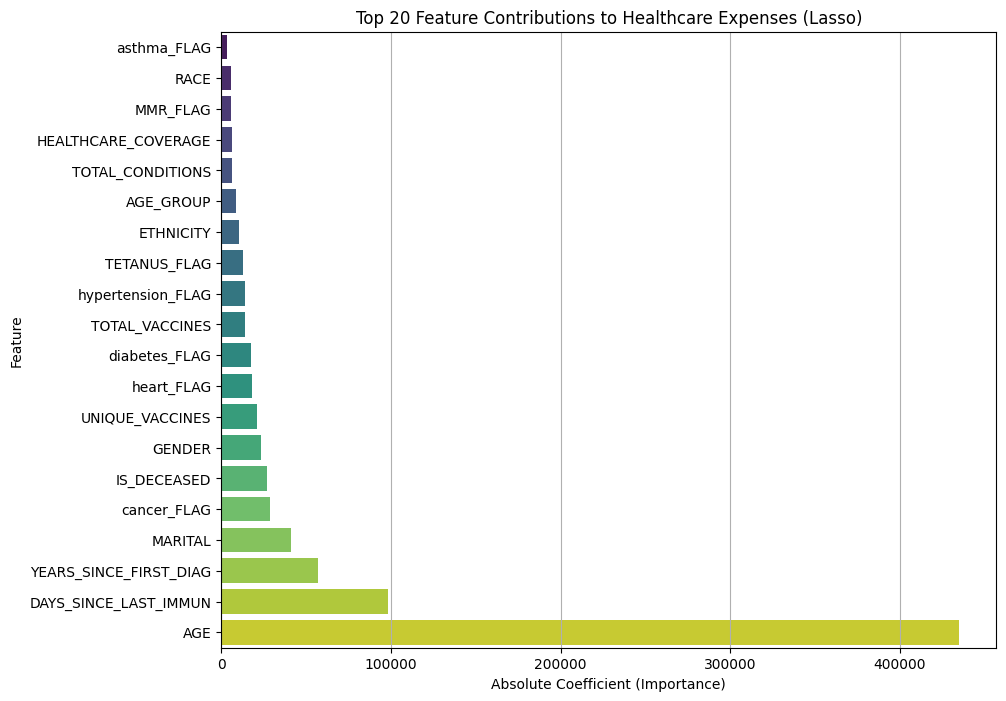

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------
# 1. Sort features by absolute coefficient
# --------------------------------------------------------
coef_df_sorted = coef_df.sort_values("AbsCoeff", ascending=True)  # ascending for horizontal bar chart

# --------------------------------------------------------
# 2. Plot top 20 features
# --------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.barplot(
    x="AbsCoeff",
    y="Feature",
    data=coef_df_sorted.tail(20),  # top 20 features
    palette="viridis"
)
plt.xlabel("Absolute Coefficient (Importance)")
plt.ylabel("Feature")
plt.title("Top 20 Feature Contributions to Healthcare Expenses (Lasso)")
plt.grid(axis="x")
plt.show()


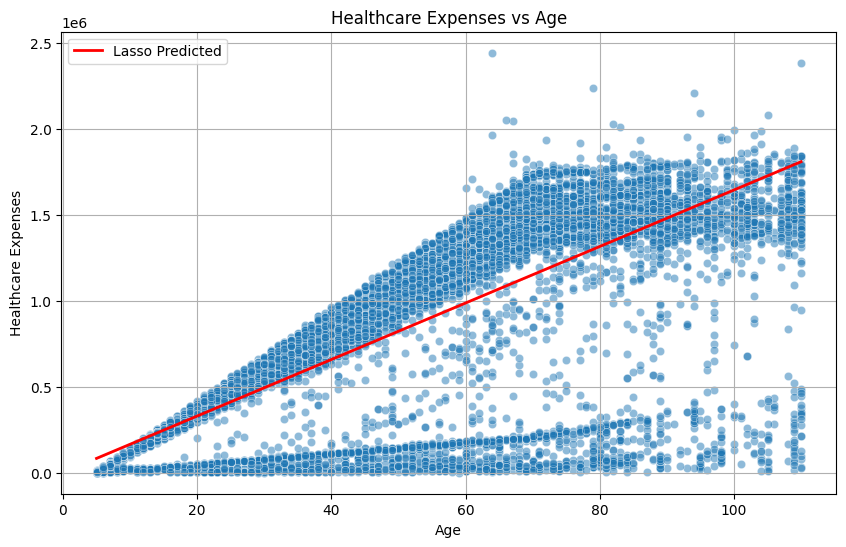

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --------------------------------------------------------
# 1. Scatter plot of AGE vs HEALTHCARE_EXPENSES
# --------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["AGE"], y=df["HEALTHCARE_EXPENSES"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Healthcare Expenses")
plt.title("Healthcare Expenses vs Age")
plt.grid(True)

# --------------------------------------------------------
# 2. Overlay Lasso-predicted trend
# --------------------------------------------------------
# Create a copy of X
X_pred = pd.DataFrame(index=df.index, columns=X.columns)

# Fill each column with the median value
for col in X.columns:
    X_pred[col] = X[col].median()

# Set AGE to the actual values to see trend
X_pred["AGE"] = df["AGE"]

# Predict using trained model
pred_expenses = pipe.predict(X_pred)

# Plot trend line
sns.lineplot(x=df["AGE"], y=pred_expenses, color="red", label="Lasso Predicted", linewidth=2)

plt.legend()
plt.show()


In [34]:
# Merge patients with conditions
df1 = patients1.merge(agg_df, left_on="Id", right_on="PATIENT", how="left")

# Merge patients+conditions with immunizations
df1 = df1.merge(immuns_df, left_on="Id", right_on="PATIENT", how="left")

drop_cols1 = [
    "ZIP"
]
df1 = df1.drop(columns=drop_cols1, errors="ignore")

# Drop duplicate PATIENT columns
df1 = df1.drop(columns=["PATIENT_x", "PATIENT_y"], errors="ignore")

# Show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)  # Optional: adjust console width

# Print first 5 rows
print(df1.head(10))

print("Final merged dataset shape:", df.shape)
print(df1.head())


                                     Id  BIRTHDATE DEATHDATE  MARITAL   RACE    ETHNICITY GENDER                        BIRTHPLACE         CITY          STATE            COUNTY        LAT  \
0  f0f3bc8d-ef38-49ce-a2bd-dfdda982b271 2017-08-24       NaT  Unknown  white  nonhispanic      M        Beverly  Massachusetts  US  Springfield  Massachusetts    Hampden County  42.151961   
1  067318a4-db8f-447f-8b6e-f2f61e9baaa5 2016-08-01       NaT  Unknown  white  nonhispanic      F         Boston  Massachusetts  US      Walpole  Massachusetts    Norfolk County  42.177370   
2  ae9efba3-ddc4-43f9-a781-f72019388548 1992-06-30       NaT        S  white  nonhispanic      M    Springfield  Massachusetts  US     Chicopee  Massachusetts    Hampden County  42.181642   
3  199c586f-af16-4091-9998-ee4cfc02ee7a 2004-01-09       NaT  Unknown  white  nonhispanic      F      Worcester  Massachusetts  US     Pembroke  Massachusetts   Plymouth County  42.075292   
4  353016ea-a0ff-4154-85bb-1cf8b6cedf20 1996-

In [ ]:
###1️⃣ Aggregate healthcare costs by city and state
#
import pandas as pd

# Aggregate by CITY
city_stats = df1.groupby("CITY").agg(
    avg_expenses=("HEALTHCARE_EXPENSES", "mean"),
    median_expenses=("HEALTHCARE_EXPENSES", "median"),
    total_patients=("Id", "count")
).sort_values("avg_expenses", ascending=False)

print("Top 10 cities by average healthcare expenses:")
print(city_stats.head(10))

# Aggregate by STATE
state_stats = df1.groupby("STATE").agg(
    avg_expenses=("HEALTHCARE_EXPENSES", "mean"),
    median_expenses=("HEALTHCARE_EXPENSES", "median"),
    total_patients=("Id", "count")
).sort_values("avg_expenses", ascending=False)

print("\nTop states by average healthcare expenses:")
print(state_stats.head(10))


Top 10 cities by average healthcare expenses:
                 avg_expenses  median_expenses  total_patients
CITY                                                          
Peru             1.743575e+06       1743574.88               1
Alford           1.616638e+06       1616637.66               1
Royalston        1.550987e+06       1525467.44               3
Tyringham        1.514758e+06       1514758.46               1
Wales            1.395167e+06       1395167.29               1
Egremont         1.368463e+06       1368462.65               2
Southampton      1.353323e+06       1540989.76              14
New Salem        1.331831e+06       1486787.43               3
New Braintree    1.326737e+06       1326736.91               1
East Brookfield  1.289025e+06       1525616.33              21

Top states by average healthcare expenses:
                avg_expenses  median_expenses  total_patients
STATE                                                        
Massachusetts  811083.150518  

C:\Users\Mahi2\AppData\Local\Temp\ipykernel_19688\3690111967.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


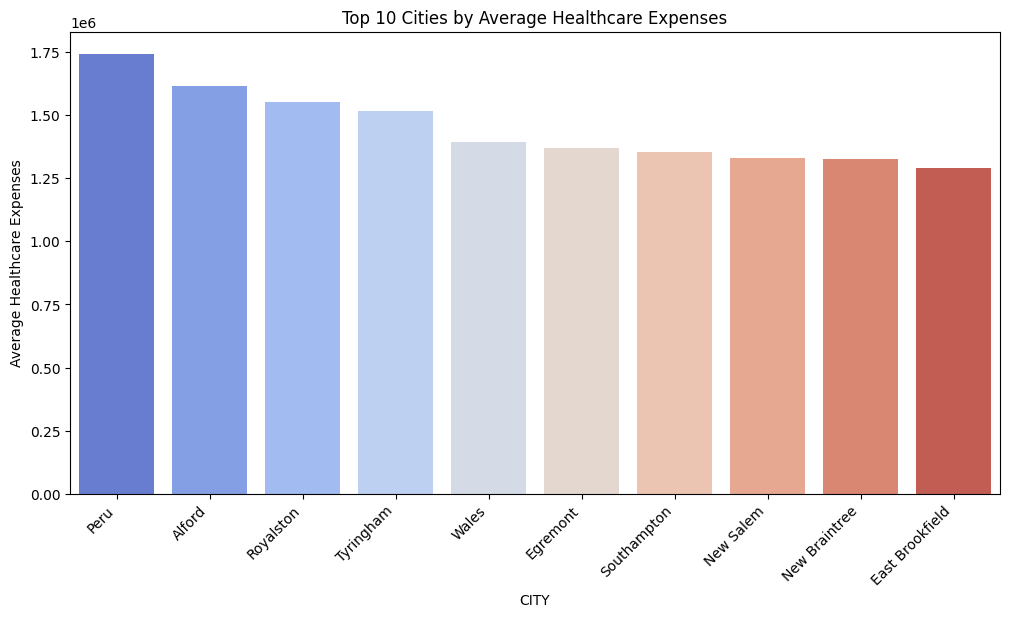

In [36]:
##2️⃣ Visualize healthcare costs across cities

import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 most expensive cities
top_cities = city_stats.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_cities.index,
    y=top_cities.avg_expenses,
    palette="coolwarm"
)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Average Healthcare Expenses")
plt.title("Top 10 Cities by Average Healthcare Expenses")
plt.show()


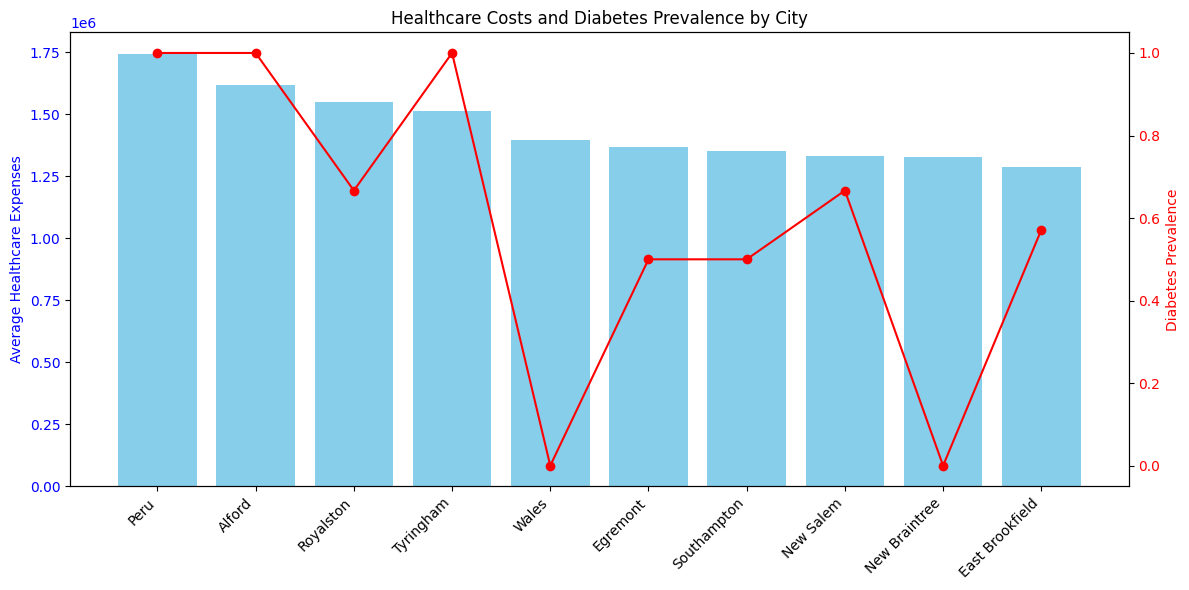

In [39]:
import matplotlib.pyplot as plt

top_cities = city_stats.head(10)  # top 10 cities by avg expenses

fig, ax1 = plt.subplots(figsize=(12,6))

# Bar plot: average expenses
ax1.bar(top_cities.index, top_cities.avg_expenses, color='skyblue', label='Avg Expenses')
ax1.set_ylabel('Average Healthcare Expenses', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45, ha='right')

# Line plot: diabetes prevalence
ax2 = ax1.twinx()
ax2.plot(top_cities.index, top_cities.diabetes_rate, color='red', marker='o', label='Diabetes Rate')
ax2.set_ylabel('Diabetes Prevalence', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Healthcare Costs and Diabetes Prevalence by City")
fig.tight_layout()
plt.show()


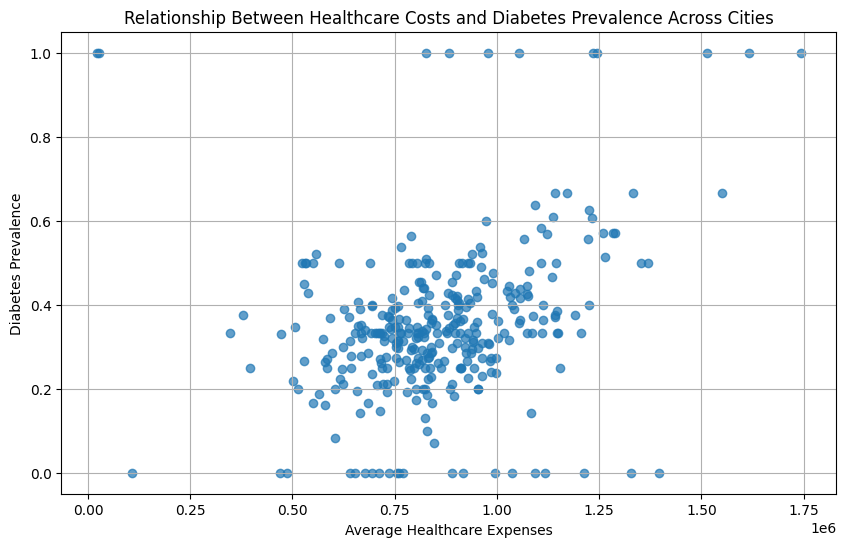

In [40]:
plt.figure(figsize=(10,6))
plt.scatter(city_stats.avg_expenses, city_stats.diabetes_rate, alpha=0.7)
plt.xlabel("Average Healthcare Expenses")
plt.ylabel("Diabetes Prevalence")
plt.title("Relationship Between Healthcare Costs and Diabetes Prevalence Across Cities")
plt.grid(True)
plt.show()
